# [Pythonによる時系列分析の基礎](https://logics-of-blue.com/python-time-series-analysis/)

- [Notebook](https://logics-of-blue.com/wp-content/uploads/2017/05/python-time-series-analysis-notebook.html)

## 準備

In [2]:
# 基本のライブラリを読み込む
#import numpy as np
#import pandas as pd
#from scipy import stats

# グラフ描画
#from matplotlib.pyplot as plt
#%matplotlib inline
#import seaborn as sns
#sns.set()

# グラフを横長にする
#from matplotlib.pylab import rcParams
#rcParams['figure.figsize'] = 15, 6

# 統計モデル
#import statsmodels.api as sm

# ワーニングを表示させない
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
# データを読み込む
# url = "https://www.analyticsvidhya.com/wp-content/uploads/2016/02/AirPassengers.csv"
url = "https://raw.githubusercontent.com/AileenNielsen/TimeSeriesAnalysisWithPython/master/data/AirPassengers.csv"

data = pd.read_csv(url, index_col='Month', parse_dates=True, dtype='float')
data.head()

# import seaborn as sns
# data = sns.load_dataset('flights')  # でもOK

,#Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


In [4]:
# 日付形式にする
ts = data['#Passengers'] 
ts.head()

Month
1949-01-01    112.0
1949-02-01    118.0
1949-03-01    132.0
1949-04-01    129.0
1949-05-01    121.0
Name: #Passengers, dtype: float64

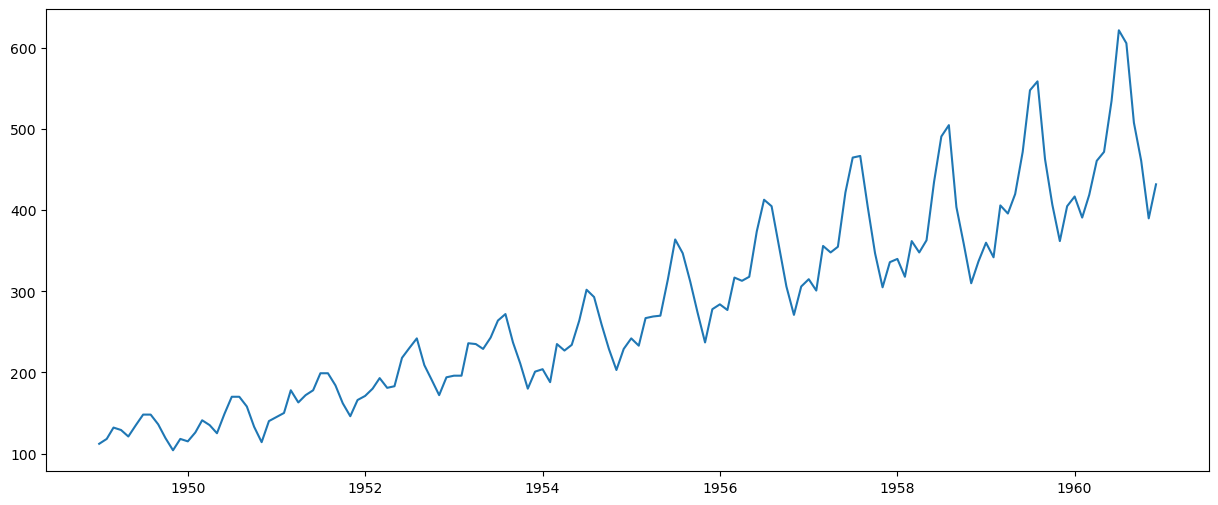

In [5]:
from matplotlib import pyplot as plt
#%matplotlib inline
plt.rcParams['figure.figsize'] = 15, 6
# プロット
plt.plot(ts)

In [6]:
# データの取得方法その1
ts['1949-01-01']

112.0

In [7]:
# データの取得方法その2
from datetime import datetime
ts[datetime(1949,1, 1)]

112.0

In [8]:
# 1949年のデータをすべて取ってくる
ts['1949']

Month
1949-01-01    112.0
1949-02-01    118.0
1949-03-01    132.0
1949-04-01    129.0
1949-05-01    121.0
1949-06-01    135.0
1949-07-01    148.0
1949-08-01    148.0
1949-09-01    136.0
1949-10-01    119.0
1949-11-01    104.0
1949-12-01    118.0
Name: #Passengers, dtype: float64

In [9]:
# シフト
ts.shift().head()

Month
1949-01-01      NaN
1949-02-01    112.0
1949-03-01    118.0
1949-04-01    132.0
1949-05-01    129.0
Name: #Passengers, dtype: float64

In [10]:
# 差分系列
ts.diff().head()

Month
1949-01-01     NaN
1949-02-01     6.0
1949-03-01    14.0
1949-04-01    -3.0
1949-05-01    -8.0
Name: #Passengers, dtype: float64

In [11]:
import numpy as np
# 対数差分系列
logDiff = np.log(ts) - np.log(ts.shift())
logDiff.head()

# NaNを取り除てから表示
#logDiff.dropna().head()

Month
1949-01-01         NaN
1949-02-01    0.052186
1949-03-01    0.112117
1949-04-01   -0.022990
1949-05-01   -0.064022
Name: #Passengers, dtype: float64

## 自己相関係数の推定

In [12]:
from scipy import stats
import statsmodels.api as sm
# 自己相関を求める
ts_acf = sm.tsa.stattools.acf(ts, nlags=40)
ts_acf

array([1.        , 0.94804734, 0.87557484, 0.80668116, 0.75262542,
       0.71376997, 0.6817336 , 0.66290439, 0.65561048, 0.67094833,
       0.70271992, 0.74324019, 0.76039504, 0.71266087, 0.64634228,
       0.58592342, 0.53795519, 0.49974753, 0.46873401, 0.44987066,
       0.4416288 , 0.45722376, 0.48248203, 0.51712699, 0.53218983,
       0.49397569, 0.43772134, 0.3876029 , 0.34802503, 0.31498388,
       0.28849682, 0.27080187, 0.26429011, 0.27679934, 0.2985215 ,
       0.32558712, 0.3370236 , 0.30333486, 0.25397708, 0.21065534,
       0.17217092])

In [13]:
# 偏自己相関
ts_pacf = sm.tsa.stattools.pacf(ts, nlags=40, method='ols')
ts_pacf

array([ 1.        ,  0.95893198, -0.32983096,  0.2018249 ,  0.14500798,
        0.25848232, -0.02690283,  0.20433019,  0.15607896,  0.56860841,
        0.29256358,  0.8402143 ,  0.61268285, -0.66597616, -0.38463943,
        0.0787466 , -0.02663483, -0.05805221, -0.04350748,  0.27732556,
       -0.04046447,  0.13739883,  0.3859958 ,  0.24203808, -0.04912986,
       -0.19599778, -0.15443575,  0.04484465,  0.18371541, -0.0906113 ,
       -0.06202938,  0.34827092,  0.09899499, -0.08396793,  0.36328898,
       -0.17956662,  0.15839435,  0.06376775, -0.27503705,  0.2707607 ,
        0.32002003])

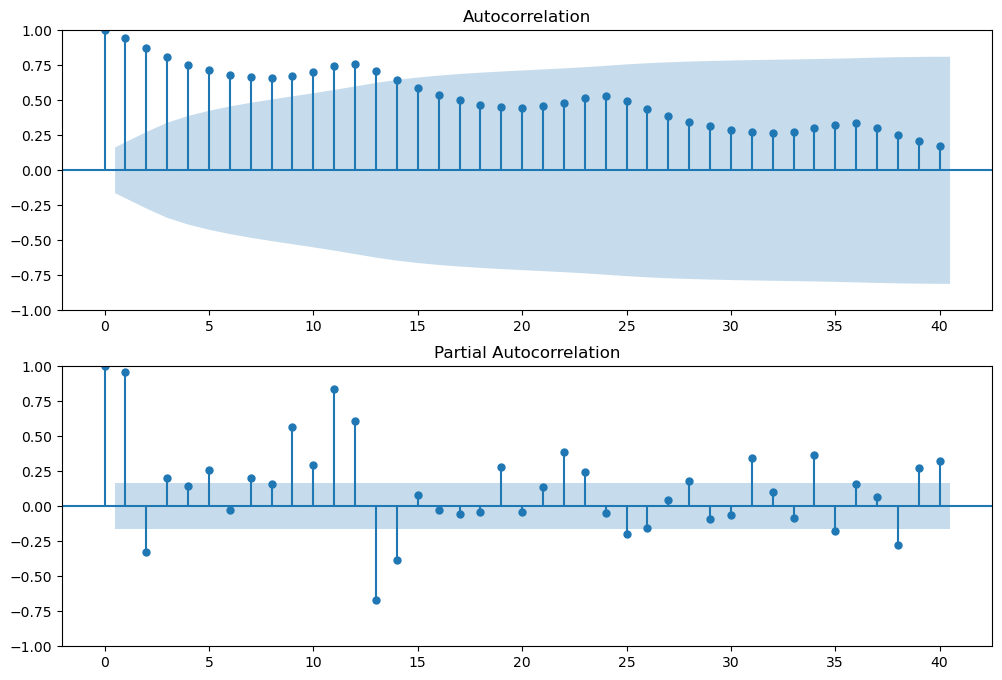

In [14]:
#  自己相関のグラフ
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=40, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts, lags=40, ax=ax2, method='ols')

## ARIMAモデルの推定

In [15]:
# たぶん和分過程なので、差分をとる
diff = ts.diff().dropna()
diff.head()

Month
1949-02-01     6.0
1949-03-01    14.0
1949-04-01    -3.0
1949-05-01    -8.0
1949-06-01    14.0
Name: #Passengers, dtype: float64

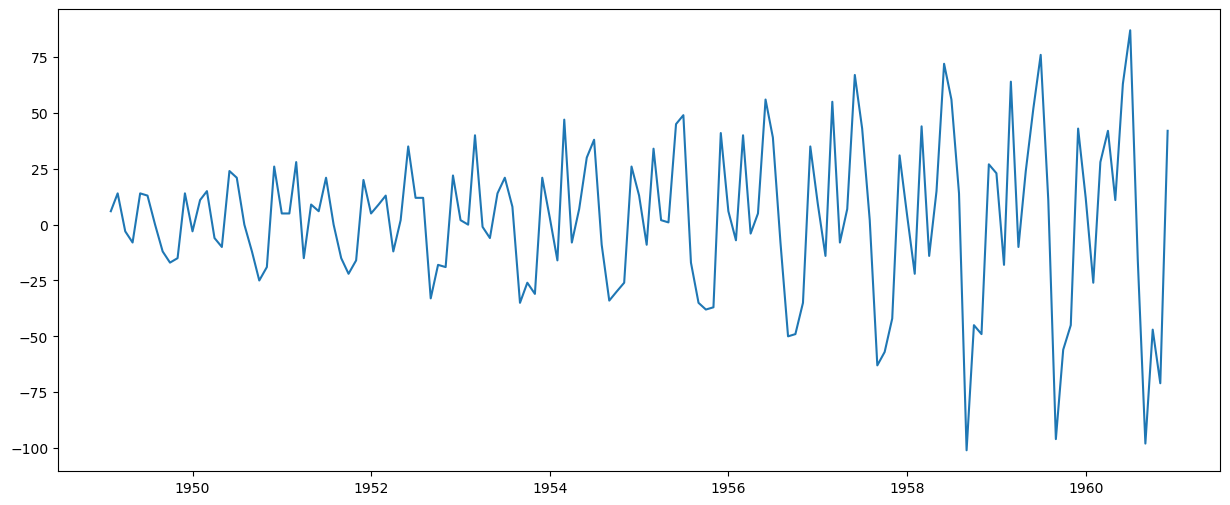

In [16]:
# 差分系列のグラフ
plt.plot(diff)

『arma_order_select_ic』という関数を使うことで、ARMAの次数を決定できます。
引数としては、対象データ、情報量規準として何を使うか（ほかにはBICなどが使えます）、そしてトレンドの有無です。

In [21]:
# 差分系列への自動ARMA推定関数の実行
resDiff = sm.tsa.arma_order_select_ic(diff, ic='aic', trend='c')
resDiff

c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


{'aic':              0            1            2
 0  1415.277587  1398.827110  1398.385532
 1  1403.473489  1396.121579  1371.815392
 2  1397.975152  1361.695809  1344.043644
 3  1396.151049  1362.451017  1360.749619
 4  1388.509998  1384.811553  1356.163967,
 'aic_min_order': (2, 2)}

In [25]:
# P-3, q=2 が最善となったので、それをモデル化
from statsmodels.tsa.arima.model import ARIMA
ARIMA_3_1_2 = ARIMA(ts, order=(3, 1, 2)).fit()
ARIMA_3_1_2.params

c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ar.L1       0.258023
ar.L2       0.373191
ar.L3      -0.336691
ma.L1       0.071226
ma.L2      -0.784621
sigma2    812.478248
dtype: float64

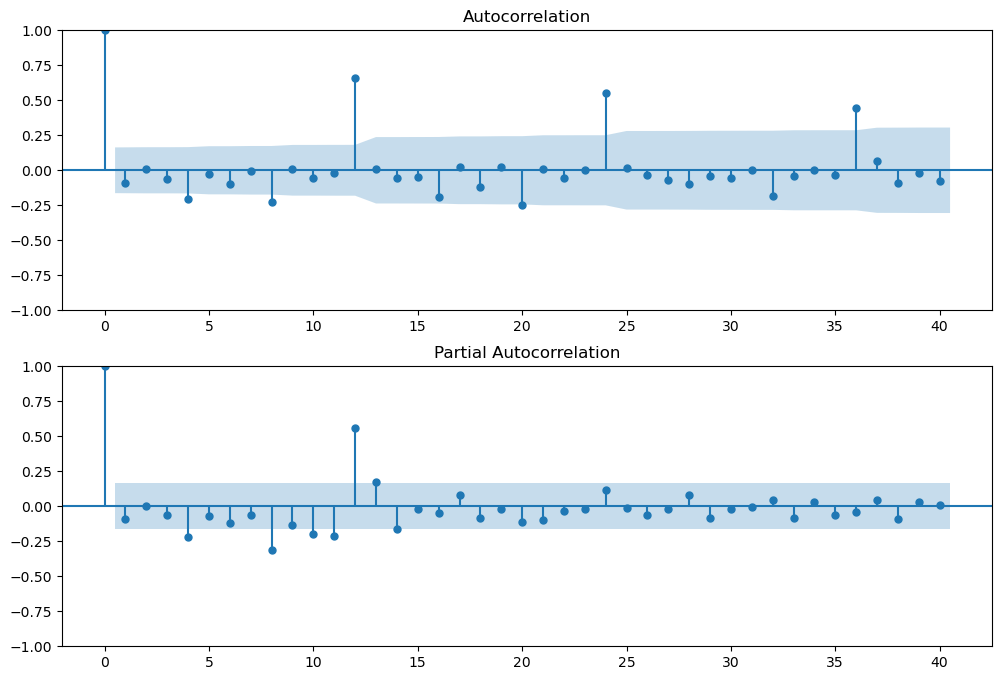

In [26]:
# 残差のチェック
# SARIMAじゃないので、周期性が残ってしまっている。。。
resid = ARIMA_3_1_2.resid
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resid.values.squeeze(), lags=40, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(resid, lags=40, ax=ax2)

## SARIMAモデルの推定

order=(3,1,2)でARIMAモデルの次数を、seasonal_order=(1,1,1,12)で季節変動の次数を設定します。
seasonal_order=(1,1,1,12)の最後の「12」は「12か月周期」であることを意味しています。なので、実質は(sp,sd,sq)=(1,1,1)です。

In [27]:
# SARIMAモデルを「決め打ち」で推定する
SARIMA_3_1_2_111 = sm.tsa.SARIMAX(
    ts, order=(3,1,2), 
    seasonal_order=(1,1,1,12)
    ).fit(method='bfgs',  maxiter=300)
print(SARIMA_3_1_2_111.summary())

c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


         Current function value: 3.493921
         Iterations: 26
         Function evaluations: 80
         Gradient evaluations: 68
                                      SARIMAX Results                                       
Dep. Variable:                          #Passengers   No. Observations:                  144
Model:             SARIMAX(3, 1, 2)x(1, 1, [1], 12)   Log Likelihood                -503.125
Date:                              Tue, 07 Jan 2025   AIC                           1022.249
Time:                                      16:26:53   BIC                           1045.251
Sample:                                  01-01-1949   HQIC                          1031.596
                                       - 12-01-1960                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------

c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


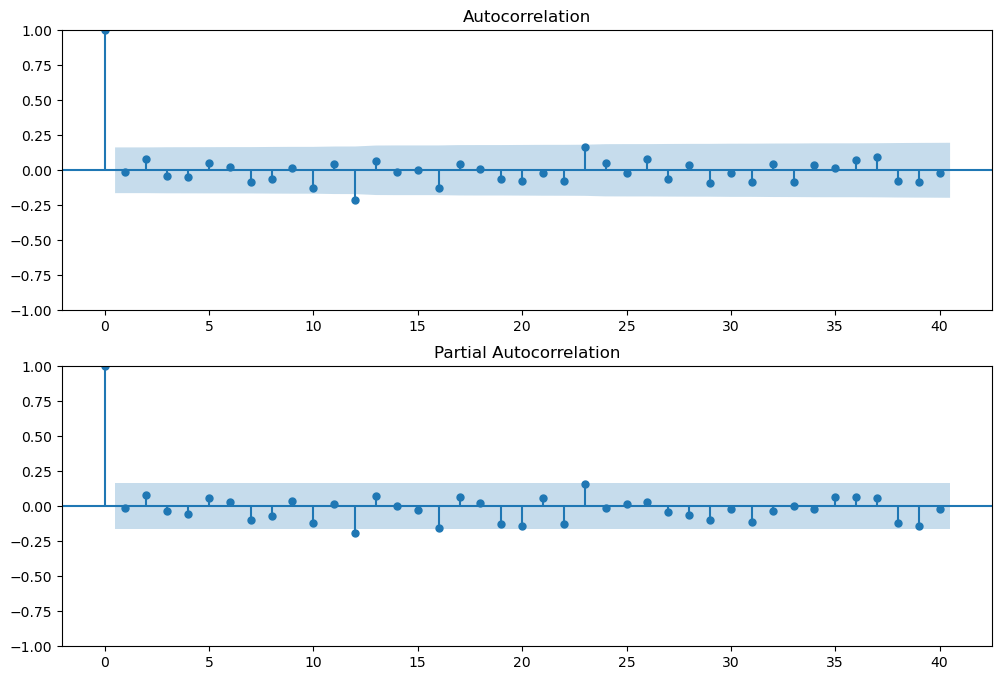

In [28]:
# 残差のチェック
residSARIMA = SARIMA_3_1_2_111.resid
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(residSARIMA.values.squeeze(), lags=40, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(residSARIMA, lags=40, ax=ax2)

予測にはそのまま『predict(予測開始日, 予測終了日)』関数を使うのですが、予測対象となる日付は「もともとのサンプルに含まれていた日付」からスタートする必要があることに注意してください。
データは1960年12月まであります。将来を予測したいのだから、1961年の1月スタートで予測したくなるのですが、そうするとエラーになります。

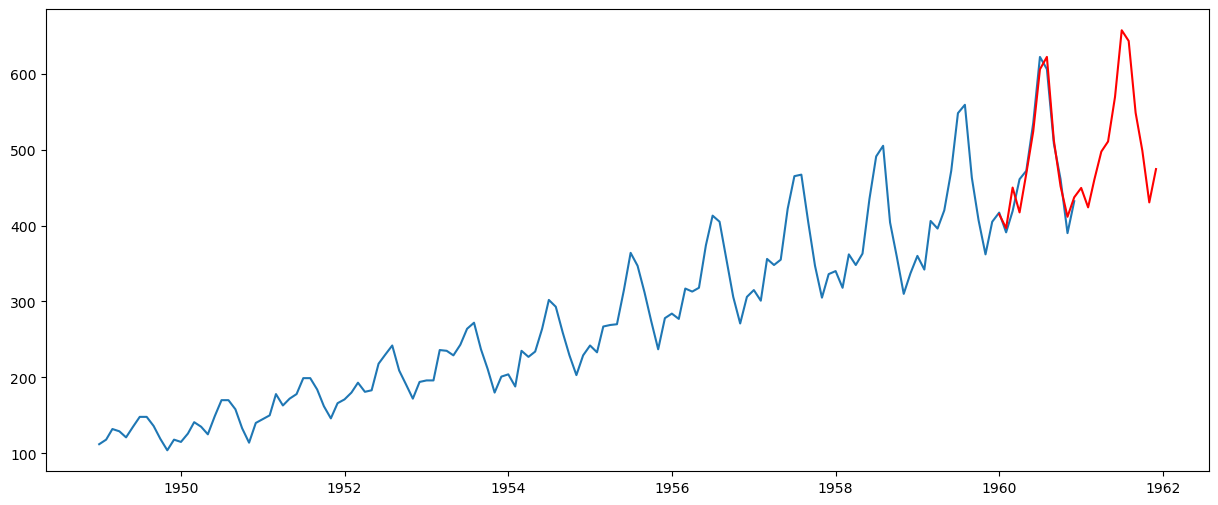

In [29]:
# 予測
pred = SARIMA_3_1_2_111.predict('1960-01-01', '1961-12-01')

# 実データと予測結果の図示
plt.plot(ts)
plt.plot(pred, "r")

## 総当たり法によるSARIMAモデル次数の決定

In [30]:
# 総当たりで、AICが最小となるSARIMAの次数を探す
max_p = 3
max_q = 3
max_d = 1
max_sp = 1
max_sd = 1
max_sq = 1

pattern = max_p*(max_q + 1)*(max_d + 1)*(max_sp + 1)*(max_sd + 1)*(max_sq + 1)

modelSelection = pd.DataFrame(index=range(pattern), columns=["model", "aic"])
pattern

192

In [31]:
# 自動SARIMA選択
#『enforce_stationarity = False』『enforce_invertibility = False』という指定をしています。
# これがないとエラーがたくさん出てきて、ループを回すどころではなくなるので注意してください。

num = 0

for p in range(1, max_p + 1):
    for d in range(0, max_d + 1):
        for q in range(0, max_q + 1):
            for sp in range(0, max_sp + 1):
                for sd in range(0, max_sd + 1):
                    for sq in range(0, max_sq + 1):
                        sarima = sm.tsa.SARIMAX(
                            ts, order=(p,d,q), 
                            seasonal_order=(sp,sd,sq,12), 
                            enforce_stationarity = False, 
                            enforce_invertibility = False
                        ).fit(method='bfgs', maxiter=300, disp=False)
                        modelSelection.iloc[num]["model"] = "order=(" + str(p) + ","+ str(d) + ","+ str(q) + "), season=("+ str(sp) + ","+ str(sd) + "," + str(sq) + ")"
                        modelSelection.iloc[num]["aic"] = sarima.aic
                        num = num + 1
modelSelection

c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency informa

,model,aic
0,"order=(1,0,0), season=(0,0,0)",1415.906882
1,"order=(1,0,0), season=(0,0,1)",1205.390778
2,"order=(1,0,0), season=(0,1,0)",1029.977309
3,"order=(1,0,0), season=(0,1,1)",944.385492
4,"order=(1,0,0), season=(1,0,0)",1017.315549
...,...,...
187,"order=(3,1,3), season=(0,1,1)",898.104538
188,"order=(3,1,3), season=(1,0,0)",992.114875
189,"order=(3,1,3), season=(1,0,1)",979.579292
190,"order=(3,1,3), season=(1,1,0)",910.007965


ここで注意してほしいのは、SARIMAX関数の中で使われている引数です。
13，14行目に各々『enforce_stationarity = False』『enforce_invertibility = False』という指定をしています。
これがないとエラーがたくさん出てきて、ループを回すどころではなくなるので注意してください。

和分過程に対して、普通の自己回帰モデルなどを適用する際に「定常過程のモデルを推定しなければならない → enforce_stationarity = True」を指定していると、そもそもモデルが推定できませんね。
普通は和分過程を相手にする場合は、必ず差分をとってから自己回帰モデルを適用するのですが、今回は次数を総当たりで変えているため、「和分過程に自己回帰モデルを適用する」という計算が行われてしまいます。
そこでエラーをなくすために無理やりこんな指定をしています。
普通は「和分過程に自己回帰モデルを適用」したような結果が選ばれることはないのですが、AIC最小だからといって手放しにそれを採用するのではなく、「まともな」次数になっているかどうかを確認してから使うようにしてください。

モデルをフィットさせる際、以下のように最適化の方法を変更＋繰り返し数を増加させると、ワーニングの数を減らすことができました。
それでもすべてではなく、いくつかはワーニングが出ます。
fit(method=’bfgs’, maxiter=300, disp=False)

選ばれた結果は過剰に信用するのではなく、ある程度疑ってかかりながら解析を進めるしかないかと思います。

In [32]:
# AIC最小モデル
modelSelection[modelSelection.aic == min(modelSelection.aic)]

,model,aic
187,"order=(3,1,3), season=(0,1,1)",898.104538


In [33]:
# AIC最小SARIMAモデルで推定する
bestSARIMA = sm.tsa.SARIMAX(
    ts, order=(3,1,3), 
    seasonal_order=(0,1,1,12), 
    enforce_stationarity = False, 
    enforce_invertibility = False
    ).fit(method='bfgs')
print(bestSARIMA.summary())

c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\miura\miniconda3\envs\py312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Optimization terminated successfully.
         Current function value: 3.062863
         Iterations: 36
         Function evaluations: 44
         Gradient evaluations: 44
                                      SARIMAX Results                                       
Dep. Variable:                          #Passengers   No. Observations:                  144
Model:             SARIMAX(3, 1, 3)x(0, 1, [1], 12)   Log Likelihood                -441.052
Date:                              Tue, 07 Jan 2025   AIC                            898.105
Time:                                      16:30:08   BIC                            920.064
Sample:                                  01-01-1949   HQIC                           907.018
                                       - 12-01-1960                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----

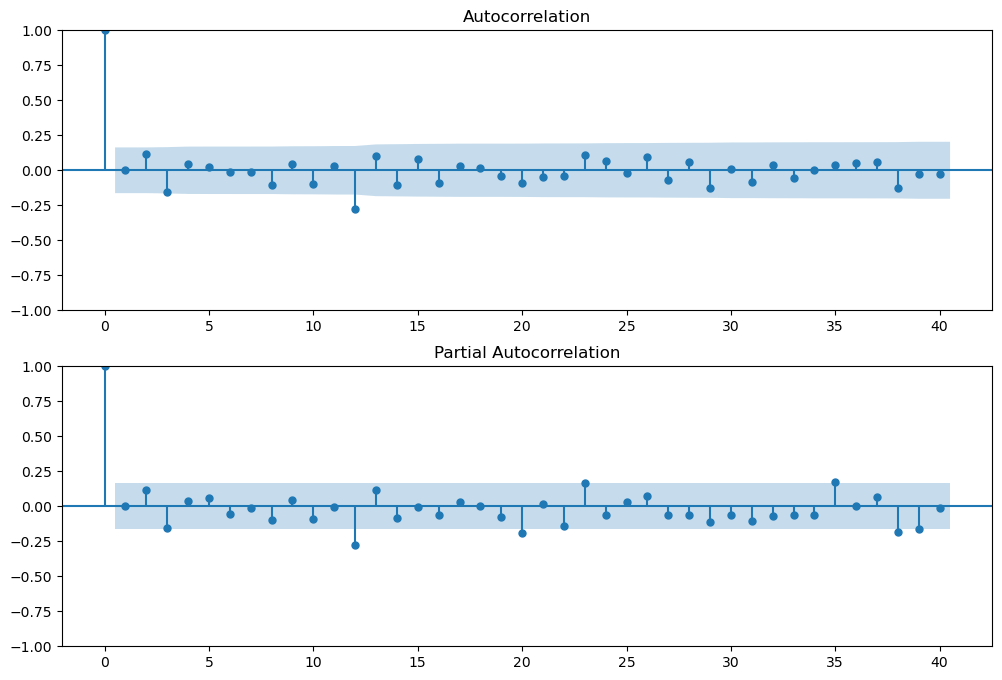

In [24]:
# 残差のチェック
residSARIMA = bestSARIMA.resid
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(residSARIMA, lags=40, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(residSARIMA, lags=40, ax=ax2)

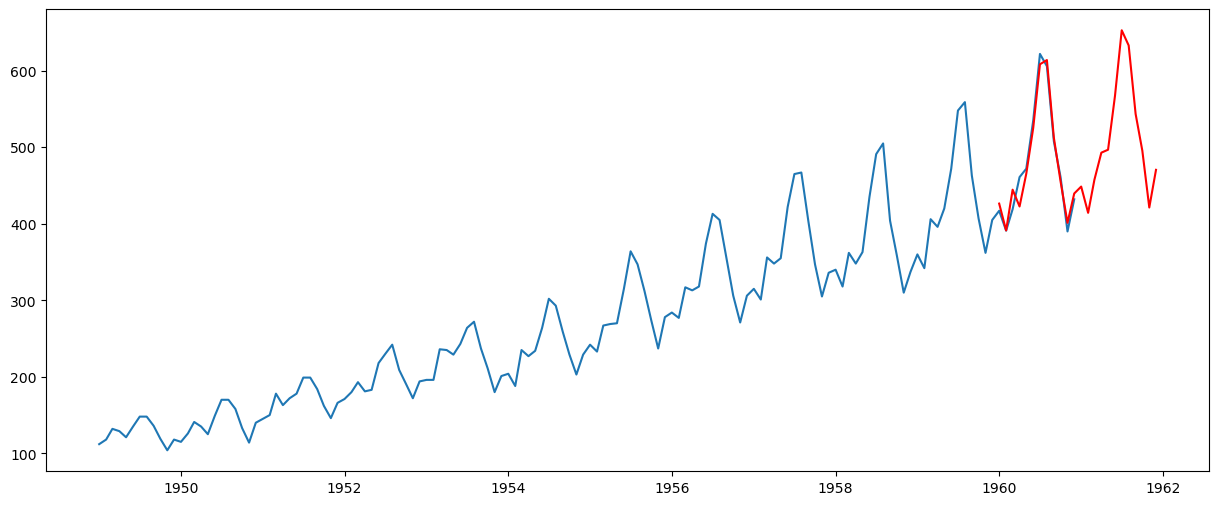

In [25]:
# 予測
bestPred = bestSARIMA.predict('1960-01-01', '1961-12-01')
# 実データと予測結果の図示
plt.plot(ts)
plt.plot(bestPred, "r")